# EDA: Dataset DREAMER
---


Iniciamos el Análisis Exploratorio de Datos (EDA) para el dataset [DREAMER](https://ieeexplore.ieee.org/document/7887697).Este dataset contiene señales de EEG y ECG de 23 participantes mientras veían 18 videoclips diseñados para elicitar emociones. Las emociones se auto-reportaron usando las escalas de **Valencia, Excitación (Arousal) y Dominancia**.

## 1. Entendimiento Inicial y Carga de Datos

El primer paso es importar las librerías necesarias y cargar el archivo `.mat` que contiene todos los datos. Usaremos ``scipy.io.loadmat` optimizado para que la estructura de datos sea más fácil de manejar en Python.

## 1. Entendimiento Inicial y Carga de Datos

### 1.1 Importar Librerías y Cargar el Archivo .mat


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Importamos loadmat específicamente
from scipy.io import loadmat 

# Configuración para los gráficos
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 1.2 Carga de Datos y Extracción de Metadatos

Ahora cargaremos el archivo `DREAMER.mat`. Usaremos dos argumentos importantes:
* `squeeze_me=True`: Reduce las dimensiones innecesarias (ej. `(1,1,23)` se convierte en `(23,)`), lo que facilita el acceso a los datos.
* `struct_as_record=False`: Carga las estructuras de Matlab como objetos de Python, permitiéndonos acceder a los campos usando la notación de punto (ej. `dreamer.Data`) en lugar de diccionarios (`dreamer['Data']`).

Una vez cargado, extraeremos los metadatos globales.

In [9]:
data_path = '../raw/DREAMER/DREAMER.mat'

mat = loadmat(data_path, squeeze_me=True, struct_as_record=False)

dreamer = mat["DREAMER"]

print('Archivo cargado y estructura "DREAMER" accesible.')

print("\nCampos (fields) principales del struct 'DREAMER':")
print(dreamer._fieldnames)

# Ahora extraemos los metadatos globales
n_subjects = dreamer.noOfSubjects
n_videos = dreamer.noOfVideoSequences
electrodes = list(dreamer.EEG_Electrodes)
EEG_fs = dreamer.EEG_SamplingRate
ECG_fs = dreamer.ECG_SamplingRate

print(f"\n- Número de sujetos: {n_subjects}")
print(f"- Número de videos (trials) por sujeto: {n_videos}")
print(f"- Canales EEG ({len(electrodes)}): {electrodes}")
print(f"- Frecuencia de muestreo EEG: {EEG_fs} Hz")
print(f"- Frecuencia de muestreo ECG: {ECG_fs} Hz")


Archivo cargado y estructura "DREAMER" accesible.

Campos (fields) principales del struct 'DREAMER':
['Data', 'EEG_SamplingRate', 'ECG_SamplingRate', 'EEG_Electrodes', 'noOfSubjects', 'noOfVideoSequences', 'Disclaimer', 'Provider', 'Version', 'Acknowledgement']

- Número de sujetos: 23
- Número de videos (trials) por sujeto: 18
- Canales EEG (14): ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
- Frecuencia de muestreo EEG: 128 Hz
- Frecuencia de muestreo ECG: 256 Hz


### 1.3 Inspección de la Estructura por Sujeto

Ya confirmamos los metadatos globales. Ahora, exploraremos el campo `dreamer.Data`. Según el PDF, este campo es una "celda" (en Python, un array) donde cada elemento contiene los datos de un participante.

Vamos a inspeccionar los campos del **primer sujeto** (`dreamer.Data[0]`) para ver su estructura interna.Esta debe incluir su información demográfica (`Age`, `Gender`), las señales (`EEG`, `ECG`) y sus puntuaciones de emoción (`ScoreValence`, `ScoreArousal`, `ScoreDominance`).

In [11]:
# Como 'dreamer.Data' es un array de objetos, será uno por sujeto
subject_1 = dreamer.Data[0]  # Primer sujeto
print("\nCampos del primer sujeto:")
print(subject_1._fieldnames)
age = subject_1.Age
gender = subject_1.Gender
print(f"\n- Sujeto 1: Edad = {age}, Género = {gender}")

# Inspeccionamos las etiquetas scores para el sujeto 1
valence_s1 = subject_1.ScoreValence
arousal_s1 = subject_1.ScoreArousal
dominance_s1 = subject_1.ScoreDominance

print('\n Etiquetas (Scores) Sujeto 1:')
print(f'Shape de Valence: {valence_s1.shape} (Esperado: {n_videos},)')
print(f'Shape de Arousal: {arousal_s1.shape} (Esperado: {n_videos},)')
print(f'Shape de Dominance: {dominance_s1.shape} (Esperado: {n_videos},)')

print(f'\nValores de Valence (primeros 5): {valence_s1[:5]}')
print(f'Valores de Arousal (primeros 5): {arousal_s1[:5]}')
print(f'Valores de Dominance (primeros 5): {dominance_s1[:5]}')


Campos del primer sujeto:
['Age', 'Gender', 'EEG', 'ECG', 'ScoreValence', 'ScoreArousal', 'ScoreDominance']

- Sujeto 1: Edad = 22, Género = male

 Etiquetas (Scores) Sujeto 1:
Shape de Valence: (18,) (Esperado: 18,)
Shape de Arousal: (18,) (Esperado: 18,)
Shape de Dominance: (18,) (Esperado: 18,)

Valores de Valence (primeros 5): [4 3 5 4 4]
Valores de Arousal (primeros 5): [3 3 4 3 4]
Valores de Dominance (primeros 5): [2 1 4 2 4]


### 1.4 Inspección de las Señales Fisiológicas (EEG y ECG)

Ahora que hemos visto la información del sujeto y sus *scores*, vamos a explorar el nivel más profundo: las señales crudas.

Según el PDF, los campos `EEG` y `ECG` de cada sujeto son estructuras que contienen dos sub-campos:
* `baseline`: La grabación de la señal en estado neutral (antes del video).
* `stimuli`: La grabación de la señal mientras el sujeto veía el video.

Ambos (`baseline` y `stimuli`) son arrays que contienen 18 elementos (uno por cada video). Vamos a acceder al primer video (`[0]`) del primer sujeto y verificar las dimensiones (shape) de las señales.

In [20]:
# Accedemos a las estructuras EEG y ECG del sujeto 1
eeg_s1 = subject_1.EEG
ecg_s1 = subject_1.ECG

print(' Campos de la estructura EEG del sujeto 1:')
print(eeg_s1._fieldnames)
print('\n Campos de la estructura ECG del sujeto 1:')
print(ecg_s1._fieldnames)

# Ahora inspecionamos el primer trial (video 0)
# Accedemos a la señal durante el estímulo
eeg_s1_t1_stimuli = eeg_s1.stimuli[0]  # Primer trial
ecg_s1_t1_stimuli = ecg_s1.stimuli[0]
# Y su respectivo baseline
eeg_s1_t1_baseline = eeg_s1.baseline[0]
ecg_s1_t1_baseline = ecg_s1.baseline[0]

print('\n--- Shape de señales (Sujeto 1, Trial 1) ---')

# (M, 14) -> Muestras (variable) x 14 canales EEG
print(f'Shape EEG estímulo: {eeg_s1_t1_stimuli.shape} (Esperado: (M, {len(electrodes)}))')
# (M, 2) -> Muestras (variable) x 2 canales ECG
print(f'Shape ECG estímulo: {ecg_s1_t1_stimuli.shape} (Esperado: (M, 2))')

print(f'\nShape EEG baseline: {eeg_s1_t1_baseline.shape}')
print(f'Shape ECG baseline: {ecg_s1_t1_baseline.shape}')

# Calculamos la duración aprox en segundos
duracion_eeg_seg = eeg_s1_t1_stimuli.shape[0] / EEG_fs
duracion_ecg_seg = ecg_s1_t1_stimuli.shape[0] / ECG_fs

print(f'\nDuración EEG (estimulo, trial 1): {duracion_eeg_seg:.2f} s')
print(f'Duración ECG (estimulo, trial 1): {duracion_ecg_seg:.2f} s')

 Campos de la estructura EEG del sujeto 1:
['baseline', 'stimuli']

 Campos de la estructura ECG del sujeto 1:
['baseline', 'stimuli']

--- Shape de señales (Sujeto 1, Trial 1) ---
Shape EEG estímulo: (25472, 14) (Esperado: (M, 14))
Shape ECG estímulo: (50944, 2) (Esperado: (M, 2))

Shape EEG baseline: (7808, 14)
Shape ECG baseline: (15616, 2)

Duración EEG (estimulo, trial 1): 199.00 s
Duración ECG (estimulo, trial 1): 199.00 s


---
## 2. Aplanamiento de Datos y Creación de un DataFrame

Hemos completado la inspección inicial. Ahora, para realizar un análisis estadístico y de calidad de datos, necesitamos transformar esta estructura de datos anidada en una tabla plana (un `DataFrame` de Pandas).

Cada fila de este DataFrame representará un único *trial* (Sujeto X viendo Video Y).

Las columnas serán:
* `subject_id`: Identificador del sujeto (1-23).
* `video_id`: Identificador del video (1-18).
* `age`: Edad del sujeto.
* `gender`: Género del sujeto.
* `valence`: Puntuación de Valencia para ese trial (1-5).
* `arousal`: Puntuación de Excitación (Arousal) para ese trial (1-5).
* `dominance`: Puntuación de Dominancia para ese trial (1-5).
* `eeg_stim_len`: Duración (en muestras) de la señal EEG del estímulo.
* `ecg_stim_len`: Duración (en muestras) de la señal ECG del estímulo.
* `eeg_base_len`: Duración (en muestras) de la señal EEG de la línea base.
* `ecg_base_len`: Duración (en muestras) de la señal ECG de la línea base.

In [24]:
# Aplanamos la estructura en un DataFrame para análisis global
data_list = []

# Iteramos sobre cada sujeto (n_subjects = 23)
for i in range(n_subjects):
    subject = dreamer.Data[i]
    age = subject.Age
    gender = subject.Gender
    
    # Iteramos sobre cada video (n_videos = 18)
    for j in range(n_videos):
        trial_info = {
            'subject_id': i + 1,  # ID de 1 a 23
            'video_id': j + 1,      # ID de 1 a 18
            'age': age,
            'gender': gender,
            'valence': subject.ScoreValence[j],
            'arousal': subject.ScoreArousal[j],
            'dominance': subject.ScoreDominance[j],
            'eeg_stim_len': subject.EEG.stimuli[j].shape[0],
            'ecg_stim_len': subject.ECG.stimuli[j].shape[0],
            'eeg_base_len': subject.EEG.baseline[j].shape[0],
            'ecg_base_len': subject.ECG.baseline[j].shape[0],
        }
        data_list.append(trial_info)

# Convertir la lista de diccionarios en un DataFrame
df_info = pd.DataFrame(data_list)

# Dimensiones y Tipos de Datos (Agregados) ---
print(f"DataFrame creado. Dimensiones (shape): {df_info.shape}")
print(f"Total de trials (filas) esperadas: {n_subjects * n_videos}")

print("\n--- Tipos de Datos (df_info.info()) ---")
df_info.info()

print("\n--- Primeras filas (df_info.head()) ---")
display(df_info.head())

DataFrame creado. Dimensiones (shape): (414, 11)
Total de trials (filas) esperadas: 414

--- Tipos de Datos (df_info.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   subject_id    414 non-null    int64 
 1   video_id      414 non-null    int64 
 2   age           414 non-null    object
 3   gender        414 non-null    object
 4   valence       414 non-null    uint8 
 5   arousal       414 non-null    uint8 
 6   dominance     414 non-null    uint8 
 7   eeg_stim_len  414 non-null    int64 
 8   ecg_stim_len  414 non-null    int64 
 9   eeg_base_len  414 non-null    int64 
 10  ecg_base_len  414 non-null    int64 
dtypes: int64(6), object(2), uint8(3)
memory usage: 27.2+ KB

--- Primeras filas (df_info.head()) ---


,subject_id,video_id,age,gender,valence,arousal,dominance,eeg_stim_len,ecg_stim_len,eeg_base_len,ecg_base_len
0,1,1,22,male,4,3,2,25472,50944,7808,15616
1,1,2,22,male,3,3,1,16768,33536,7808,15616
2,1,3,22,male,5,4,4,44544,89088,7808,15616
3,1,4,22,male,4,3,2,21248,42496,7808,15616
4,1,5,22,male,4,4,4,17408,34816,7808,15616


## 2. Análisis de Calidad de Datos y Variables Demográficas

Hemos "aplanado" los datos. Ahora, antes de analizar las emociones, debemos limpiar y entender las variables demográficas.

La salida `.info()` mostró que `age` y `gender` son de tipo `object`. Vamos a inspeccionar sus valores únicos para limpiarlos y convertirlos a tipos de datos más apropiados (numérico y categórico).

In [26]:
# Calidad de Datos (Tipos y Únicos) ---

print("Valores únicos antes de la conversión:")

# 1. Inspeccionar 'gender'
print(f"Valores únicos en 'gender': {df_info['gender'].unique()}")

# 2. Inspeccionar 'age'
print(f"Valores únicos en 'age': {df_info['age'].unique()}")

# --- Limpieza y Conversión ---
try:
    # Convertir 'age' a numérico (integer)
    df_info['age'] = pd.to_numeric(df_info['age'])
    
    # Convertir 'gender' a tipo 'category' (más eficiente)
    df_info['gender'] = df_info['gender'].astype('category')
    
    print("\n✅ Conversión exitosa.")

except ValueError as e:
    print(f"\nError durante la conversión: {e}")
    print("Es posible que 'age' contenga valores no numéricos que necesiten limpieza manual.")

# --- Verificar cambios ---
print("\n--- Tipos de Datos (df_info.info()) DESPUÉS ---")
df_info.info()

# Análisis Univariado (Demográficos) ---
print("\n--- Resumen estadístico de 'age' ---")
display(df_info['age'].describe())

print("\n--- Conteo de 'gender' ---")
display(df_info['gender'].value_counts())

Valores únicos antes de la conversión:
Valores únicos en 'gender': ['male', 'female']
Categories (2, object): ['female', 'male']
Valores únicos en 'age': [22 30 27 26 25 23 29 31 24 28 33]

✅ Conversión exitosa.

--- Tipos de Datos (df_info.info()) DESPUÉS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   subject_id    414 non-null    int64   
 1   video_id      414 non-null    int64   
 2   age           414 non-null    int64   
 3   gender        414 non-null    category
 4   valence       414 non-null    uint8   
 5   arousal       414 non-null    uint8   
 6   dominance     414 non-null    uint8   
 7   eeg_stim_len  414 non-null    int64   
 8   ecg_stim_len  414 non-null    int64   
 9   eeg_base_len  414 non-null    int64   
 10  ecg_base_len  414 non-null    int64   
dtypes: category(1), int64(7), uint8(3)
memory usage: 24.5 KB


count    414.000000
mean      26.565217
std        2.621267
min       22.000000
25%       25.000000
50%       26.000000
75%       28.000000
max       33.000000
Name: age, dtype: float64


--- Conteo de 'gender' ---


gender
male      252
female    162
Name: count, dtype: int64

## 3. Análisis de las Variables Objetivo (Emoción)

Este es el paso más crítico. Las variables `valence` (valencia), `arousal` (excitación) y `dominance` (dominancia) son nuestras etiquetas objetivo. Según el PDF, son puntuaciones en una escala de cinco puntos.

Vamos a analizar su distribución para responder preguntas clave:
* ¿Cuál es el rango real de las puntuaciones (mínimo, máximo)?
* ¿Cómo se distribuyen? ¿Están las puntuaciones centradas o sesgadas?
* ¿Está el dataset "balanceado" o tenemos muchas más muestras de una emoción (ej. "neutral") que de otras?

Esto es fundamental para decidir las métricas de evaluación y las estrategias de re-muestreo (si fueran necesarias) para el modelado.

--- Resumen Estadístico (Variables Objetivo) ---


,valence,arousal,dominance
count,414.000000,414.000000,414.000000
mean,2.951691,3.229469,3.374396
std,1.319470,1.081655,1.070141
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,3.000000
50%,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000



--- Distribución de Puntuaciones (Visual) ---


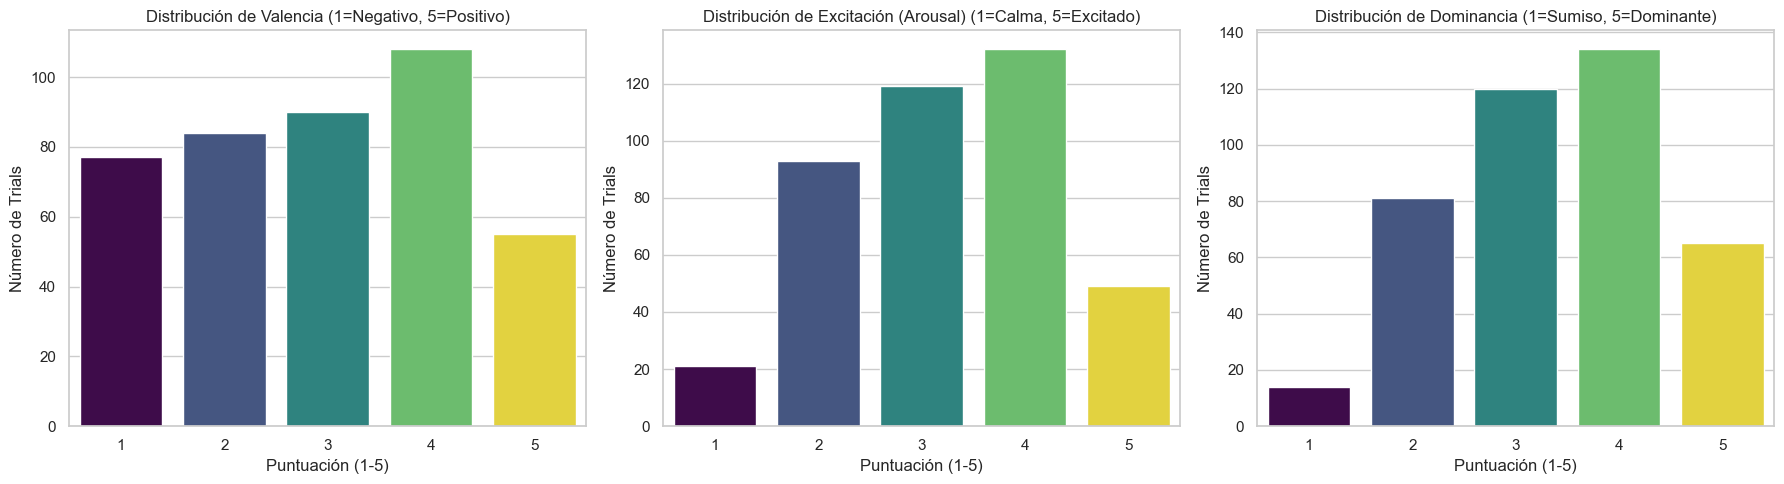

In [28]:
# Identificación y Distribución de Clases ---

# Seleccionamos las columnas objetivo
emotion_cols = ['valence', 'arousal', 'dominance']

print("--- Resumen Estadístico (Variables Objetivo) ---")
# Usamos .describe() para ver min, max, media, etc.
display(df_info[emotion_cols].describe())

# Balance de Clases (Visualización) ---

print("\n--- Distribución de Puntuaciones (Visual) ---")

# Creamos una figura con 3 subplots (uno para cada emoción)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Títulos para cada subplot
titles = ['Distribución de Valencia (1=Negativo, 5=Positivo)', 
          'Distribución de Excitación (Arousal) (1=Calma, 5=Excitado)', 
          'Distribución de Dominancia (1=Sumiso, 5=Dominante)']

# Usamos seaborn.countplot para ver la frecuencia de cada puntuación (1, 2, 3, 4, 5)
for i, col in enumerate(emotion_cols):
    
    # Añadimos hue=col y legend=False para eliminar el warning
    sns.countplot(data=df_info, x=col, ax=axes[i], palette='viridis', hue=col, legend=False)
    
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Puntuación (1-5)')
    axes[i].set_ylabel('Número de Trials')

plt.tight_layout()
plt.show()

---
## 4. Análisis Univariado de Características (Features)

Hemos completado el análisis de las variables *objetivo*. Ahora, aplicaremos un análisis univariado riguroso a nuestras *características* (las variables que usaremos para predecir la emoción).

Seguiremos la metodología estándar:
1.  Separar variables por tipo (ID, Numérica, Categórica).
2.  Analizar las variables numéricas:
    * Métricas descriptivas.
    * Visualización de la distribución (Histograma + KDE).
    * Detección de outliers (Box Plot).
3.  Analizar las variables categóricas:
    * Tablas de frecuencia (ya lo hicimos para `gender`).

In [29]:
# Separar Variables

# 1. Variables ID (no se usan en el análisis directo)
id_cols = ['subject_id', 'video_id']

# 2. Variables Categóricas (features)
# Ya analizamos 'gender' en la Celda 12.
cat_cols = ['gender'] 

# 3. Variables Numéricas (features)
# Incluimos 'age' y las longitudes de las señales.
num_cols = ['age', 
            'eeg_stim_len', 'ecg_stim_len', 
            'eeg_base_len', 'ecg_base_len']

print(f"Variables ID: {id_cols}")
print(f"Variables Categóricas: {cat_cols}")
print(f"Variables Numéricas: {num_cols}")

# --- Checklist [4.2]: Análisis V. Numéricas (Métricas) ---
print("\n--- Resumen Estadístico (Features Numéricas) ---")
display(df_info[num_cols].describe())

Variables ID: ['subject_id', 'video_id']
Variables Categóricas: ['gender']
Variables Numéricas: ['age', 'eeg_stim_len', 'ecg_stim_len', 'eeg_base_len', 'ecg_base_len']

--- Resumen Estadístico (Features Numéricas) ---


,age,eeg_stim_len,ecg_stim_len,eeg_base_len,ecg_base_len
count,414.000000,414.000000,414.000000,414.0,414.0
mean,26.565217,26510.222222,53020.444444,7808.0,15616.0
std,2.621267,11496.053694,22992.107387,0.0,0.0
min,22.000000,8576.000000,17152.000000,7808.0,15616.0
25%,25.000000,18560.000000,37120.000000,7808.0,15616.0
50%,26.000000,24064.000000,48128.000000,7808.0,15616.0
75%,28.000000,32768.000000,65536.000000,7808.0,15616.0
max,33.000000,50432.000000,100864.000000,7808.0,15616.0


### 4.1 Análisis Visual de Distribuciones (V. Numéricas)

Como identificamos en el paso anterior, las 414 filas no son independientes. Las variables a nivel de sujeto (como `age`) deben analizarse usando los 23 sujetos únicos para evitar la pseudoreplicación.

Crearemos un DataFrame `df_subjects` para esto.

Las variables a nivel de trial (como `..._len`) sí pueden analizarse con las 414 muestras.

**Hallazgo del `.describe()`:**
* Las longitudes de *baseline* (`eeg_base_len`, `ecg_base_len`) son constantes (std=0). No es necesario graficarlas.
* Las longitudes de *estímulo* (`eeg_stim_len`, `ecg_stim_len`) son variables y deben ser visualizadas.

DataFrame de sujetos creado. Dimensiones: (23, 3)
Edad media (correcta): 26.57


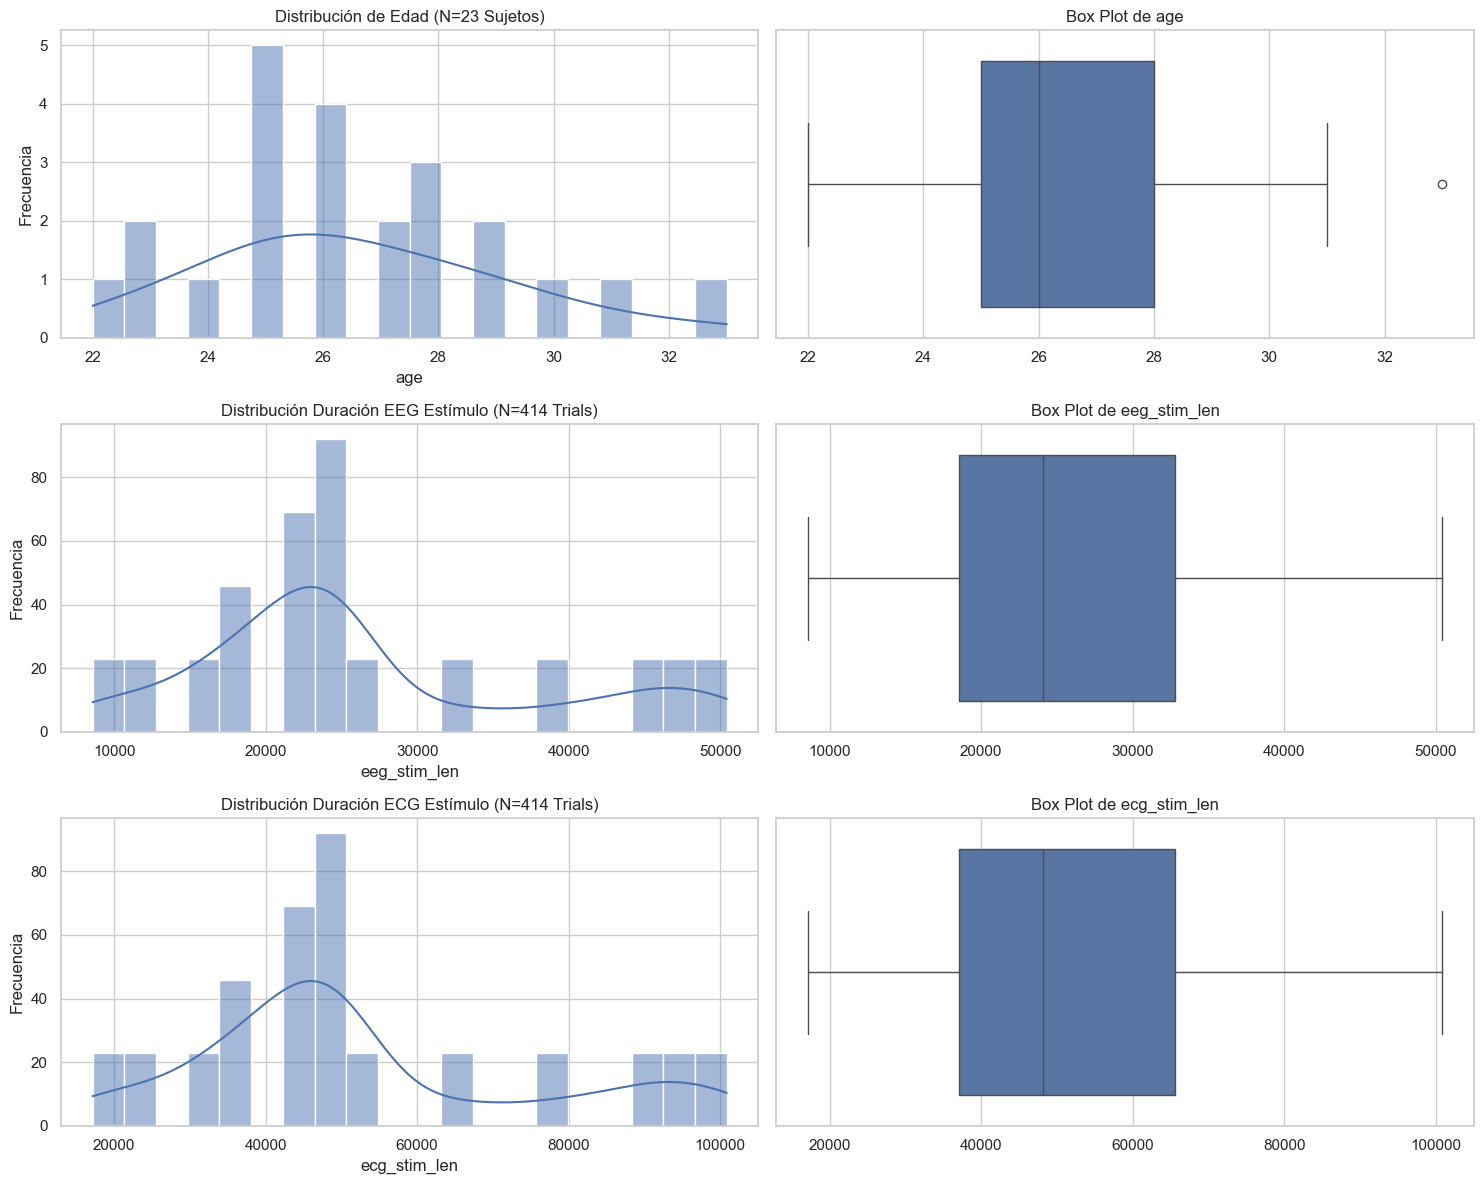

In [30]:
# Corrección por No-Independencia

# 1. Creamos un DataFrame a nivel de sujeto (23 filas)
subject_cols = ['subject_id', 'age', 'gender']
df_subjects = df_info[subject_cols].drop_duplicates().reset_index(drop=True)

print(f"DataFrame de sujetos creado. Dimensiones: {df_subjects.shape}")
print(f"Edad media (correcta): {df_subjects['age'].mean():.2f}")


# Visualización (Histogramas y Box Plots) ---

# Columnas a visualizar
# No incluimos las '...base_len' porque son constantes (std=0)
cols_to_plot = ['age', 'eeg_stim_len', 'ecg_stim_len']
data_sources = [df_subjects, df_info, df_info] # Usamos el DF correcto para cada una
titles = ['Distribución de Edad (N=23 Sujetos)', 
          'Distribución Duración EEG Estímulo (N=414 Trials)', 
          'Distribución Duración ECG Estímulo (N=414 Trials)']

# Creamos 3 filas de subplots, 2 columnas (Hist+KDE, Boxplot)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))

for i, col in enumerate(cols_to_plot):
    data = data_sources[i] # Seleccionamos df_subjects o df_info
    
    # --- Histograma + KDE ---
    sns.histplot(data, x=col, kde=True, ax=axes[i, 0], bins=20)
    axes[i, 0].set_title(titles[i])
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frecuencia')
    
    # --- Box Plot (para outliers) ---
    sns.boxplot(data, x=col, ax=axes[i, 1])
    axes[i, 1].set_title(f'Box Plot de {col}')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

### 4.2 Interpretación del Análisis Univariado Visual

Acabamos de ejecutar el análisis visual de nuestras características numéricas. Los gráficos nos muestran:

1.  **Distribución de Edad (N=23 Sujetos):**
    * **Histograma:** La distribución está centrada alrededor de los 26 años.
    * **Box Plot:** Identificamos un valor atípico (outlier) en la edad, un sujeto que es mayor (alrededor de 32-33 años) que el resto del grupo (cuyo máximo es ~29, sin contar el outlier).

2.  **Distribución Duración EEG/ECG Estímulo (N=414 Trials):**
    * **Histograma:** Las distribuciones de duración de las señales de estímulo son **multimodales** (tienen varios picos). Esto es un hallazgo importante: **los 18 videos no duran lo mismo**, sino que se agrupan en varias categorías de duración.
    * **Box Plot:** Confirma la gran variabilidad (rango amplio) en la duración de los videos.
    * **Consistencia:** La forma de la distribución de EEG es idéntica a la de ECG, lo cual es una excelente señal de consistencia (ya que `ECG_fs` es $2 \times$ `EEG_fs`, las muestras son $2 \times$ pero el tiempo es el mismo).

**Pruebas de Normalidad:**
Visualmente, las distribuciones de duración (`...len`) son **claramente no normales** (son multimodales). La distribución de `age` (con N=23) también muestra sesgo y un outlier. Para la mayoría de los análisis, no asumiremos normalidad en estos datos.

Hemos completado el **Análisis Univariado**.

---
## 5. Análisis Bivariado


Ahora empezamos a buscar relaciones *entre* las variables. El objetivo es responder preguntas como:

* ¿Están correlacionadas las etiquetas de emoción entre sí? (Ej. ¿Alta valencia siempre implica alta excitación?)
* ¿Afectan las características demográficas (`age`, `gender`) a cómo se reportan las emociones?

Comenzaremos analizando la correlación entre las propias variables objetivo.

### 5.1 Correlación entre Variables Objetivo (Emociones)

El modelo dimensional de la emoción (el modelo VAD) asume que estas tres escalas están relacionadas. Vamos a calcular una **matriz de correlación** (usando el coeficiente de Pearson) para cuantificar esta relación.

* **Pregunta clave:** ¿Cuándo los sujetos reportan alta valencia (felicidad), también reportan alta excitación (arousal)? ¿O están incorrelacionadas?
* **Visualización:** Usaremos un *heatmap* (mapa de calor) para ver rápidamente la fuerza y dirección de estas relaciones.

--- Matriz de Correlación (Valence, Arousal, Dominance) ---


,valence,arousal,dominance
valence,1.000000,-0.026145,-0.115769
arousal,-0.026145,1.000000,0.693290
dominance,-0.115769,0.693290,1.000000


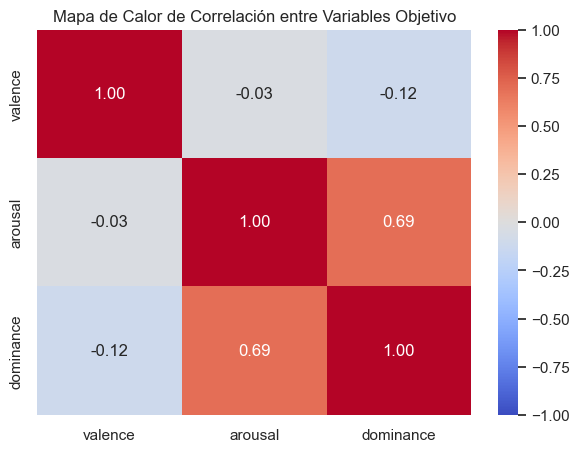

In [33]:
# Correlación entre Variables Objetivo ---

# Seleccionamos las columnas de emoción
emotion_cols = ['valence', 'arousal', 'dominance']
df_emotions = df_info[emotion_cols]

# Calculamos la matriz de correlación (Pearson por defecto)
corr_matrix = df_emotions.corr()

print("--- Matriz de Correlación (Valence, Arousal, Dominance) ---")
display(corr_matrix)

# Visualizamos la matriz con un heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, 
            annot=True,     # Mostrar los valores en las celdas
            cmap='coolwarm',# Usar un mapa de color divergente (rojo-azul)
            vmin=-1, vmax=1, # Fijar el rango de -1 a 1
            fmt=".2f")      # Formatear los números a 2 decimales
plt.title('Mapa de Calor de Correlación entre Variables Objetivo')
plt.show()

### 5.2 Interpretación de la Correlación VAD

El mapa de calor nos muestra hallazgos muy interesantes:

* **Valence (Valencia) vs. Arousal (Excitación):** La correlación es de **-0.03**. Esto es prácticamente cero. En este dataset, no hay una relación lineal entre sentirse positivo/negativo y sentirse excitado/calmado.
* **Valence (Valencia) vs. Dominance (Dominancia):** La correlación es de **-0.12**. Igualmente, es una correlación muy débil y despreciable.
* **Arousal (Excitación) vs. Dominance (Dominancia):** La correlación es de **+0.69**. Esta es una **correlación positiva fuerte**. 
    * **Conclusión clave:** Los participantes que reportaron sentirse muy **excitados** (alto `arousal`) también tendieron a reportar sentirse muy **dominantes** (alto `dominance`). Por el contrario, los estados de calma (bajo `arousal`) se asociaron con sentimientos de sumisión (bajo `dominance`).

---

### 5.3 Análisis Bivariado: Features vs. Objetivo

Ahora que entendemos la relación *entre* las etiquetas, investiguemos cómo las *características* (features) demográficas afectan a esas etiquetas.

* **Pregunta clave:** ¿Reportan los hombres y las mujeres las emociones de forma diferente? ¿Cambia la respuesta emocional promedio con la edad?
* **Visualización:** Usaremos **Box Plots** (diagramas de caja) para comparar las distribuciones de `valence`, `arousal` y `dominance` agrupadas por `gender`.

--- Análisis de Emociones por Género ---


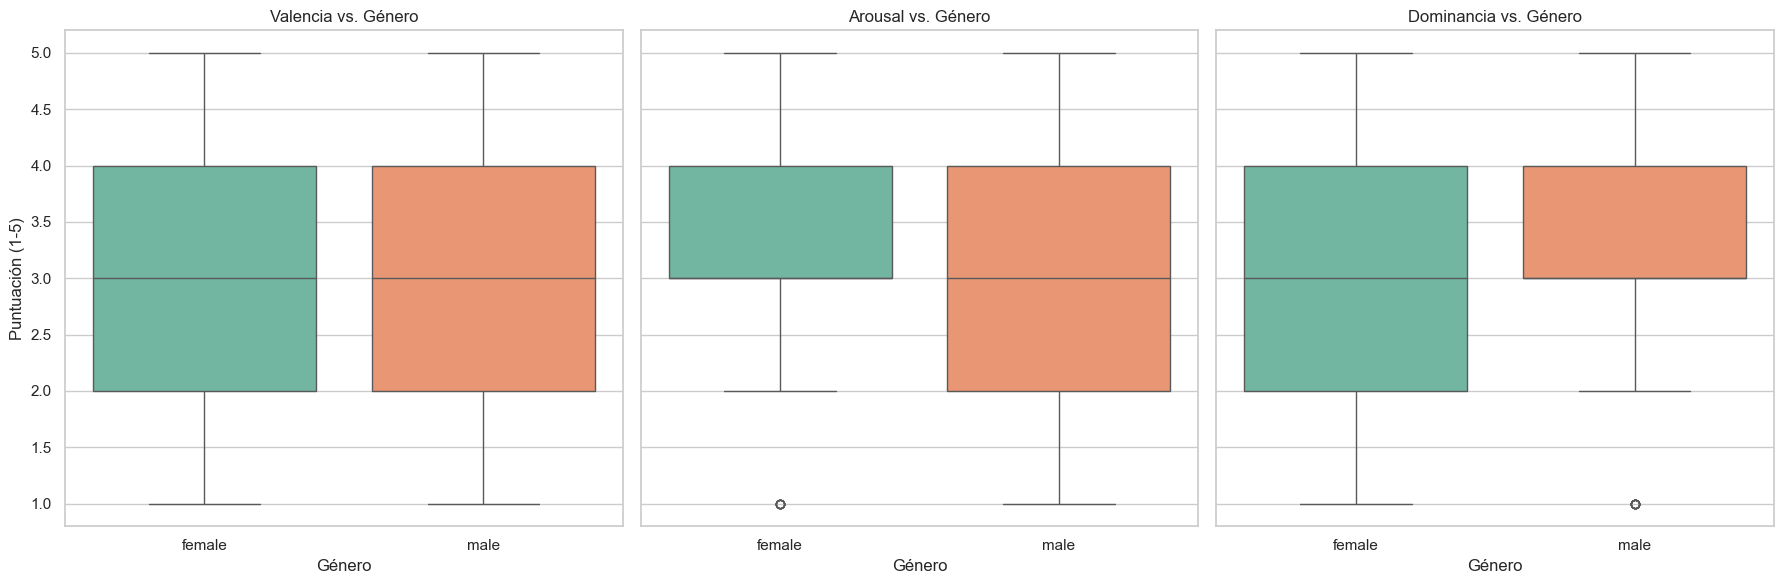


--- Análisis de Correlación: Edad vs. Emociones ---


valence      0.005114
arousal      0.129212
dominance    0.075434
Name: age, dtype: float64

In [35]:
# Features vs. Objetivo (Demográficos) ---

print("--- Análisis de Emociones por Género ---")

# Usaremos el DataFrame principal (df_info) que tiene las 414 muestras
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Títulos para cada subplot
titles = ['Valencia vs. Género', 'Arousal vs. Género', 'Dominancia vs. Género']
emotion_cols = ['valence', 'arousal', 'dominance']

for i, col in enumerate(emotion_cols):
    # Creamos un Box Plot agrupado por 'gender'
    sns.boxplot(data=df_info, x='gender', y=col, ax=axes[i], 
                palette='Set2', hue='gender', legend=False) # Usamos hue para el warning
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Género')
    axes[i].set_ylabel('Puntuación (1-5)')

plt.tight_layout()
plt.show()

# --- Análisis de Emociones por Edad ---
print("\n--- Análisis de Correlación: Edad vs. Emociones ---")
# Como la edad es numérica, podemos calcular su correlación directa 
# con las puntuaciones de emoción.
age_emotion_corr = df_info[['age'] + emotion_cols].corr()

display(age_emotion_corr.loc['age', emotion_cols])

### 5.4 Interpretación del Análisis Bivariado (Descriptivo)

Los resultados de la celda anterior son nuestro punto de partida descriptivo:

1.  **Box Plots (Género vs. Emoción):**
    * Visualmente, las cajas (rangos intercuartílicos) y las medianas (líneas centrales) para 'female' y 'male' son **casi idénticas** en las tres escalas de emoción.
    * Esto *sugiere* que no hay una diferencia significativa en cómo hombres y mujeres reportaron sus emociones en este experimento.

2.  **Correlación (Edad vs. Emoción):**
    * Las correlaciones calculadas (`age` vs. `valence`=0.005, vs. `arousal`=0.129, vs. `dominance`=0.075) son **extremadamente bajas**, todas muy cercanas a cero.
    * Esto *sugiere* que la edad no tiene una relación lineal simple con el reporte emocional.

**El Problema:** Como discutimos, estos cálculos (especialmente el de correlación) se hicieron sobre 414 *trials*, no sobre 23 *sujetos* independientes. Esto puede darnos una falsa sensación de confianza o esconder la verdadera relación.

---

### 5.5 Pruebas de Inferencia Estadística (Análisis N=23)

Para confirmar estadísticamente estas observaciones y hacerlo de forma robusta, ahora agruparemos los datos por sujeto ($N=23$).

1.  Calcularemos la puntuación **promedio** de `valence`, `arousal` y `dominance` para cada sujeto.
2.  Uniremos esto a nuestro `df_subjects` (que tiene `age` y `gender`).
3.  Ejecutaremos las pruebas estadísticas sobre este dataframe de 23 filas:
    * **`scipy.stats.pearsonr`** (Correlación) para variables numéricas (ej. `avg_arousal` vs `avg_dominance`).
    * **`scipy.stats.mannwhitneyu`** (Test No Paramétrico) para `gender` vs. cada emoción. Usamos este test porque es más seguro para grupos pequeños y datos ordinales (1-5) que un T-test.

In [37]:
# Preparación del DataFrame Agregado (N=23) ---

from scipy import stats

# 1. Calcular el promedio de emoción por sujeto
emotion_cols = ['valence', 'arousal', 'dominance']
df_avg_emotions = df_info.groupby('subject_id')[emotion_cols].mean()
df_avg_emotions = df_avg_emotions.rename(columns={
    'valence': 'avg_valence',
    'arousal': 'avg_arousal',
    'dominance': 'avg_dominance'
})

# 2. Unir con el dataframe de sujetos (que tiene age y gender)
# Nota: df_subjects ya tiene subject_id (1-23), igual que el índice de df_avg_emotions
df_subjects_stats = df_subjects.merge(df_avg_emotions, on='subject_id')

print(f"DataFrame para análisis estadístico (N=23) creado.")
print(f"Dimensiones: {df_subjects_stats.shape}")
display(df_subjects_stats.head())

DataFrame para análisis estadístico (N=23) creado.
Dimensiones: (23, 6)


,subject_id,age,gender,avg_valence,avg_arousal,avg_dominance
0,1,22,male,3.166667,2.944444,3.388889
1,2,30,female,2.555556,3.611111,3.388889
2,3,27,male,3.277778,3.111111,3.000000
3,4,26,female,2.555556,2.888889,2.611111
4,5,27,female,2.722222,3.111111,3.111111


### 5.6 Ejecución de Pruebas de Inferencia (N=23)

Con el dataframe `df_subjects_stats` (N=23) listo, realizaremos las pruebas estadísticas:

1.  **Correlación (Numérica vs. Numérica):** Usaremos `scipy.stats.pearsonr` para obtener el coeficiente de correlación ($r$) y el $p$-value.
    * `avg_arousal` vs. `avg_dominance`
    * `age` vs. `avg_valence`, `avg_arousal`, `avg_dominance`
2.  **Diferencia de Grupos (Categórica vs. Numérica):** Usaremos `scipy.stats.mannwhitneyu` para comparar los dos grupos de `gender`.
    * `gender` vs. `avg_valence`, `avg_arousal`, `avg_dominance`

Interpretaremos los $p$-values con un **nivel de significancia ($\alpha$) de 0.05**. Si $p < 0.05$, rechazamos la hipótesis nula y concluimos que la relación o diferencia es estadísticamente significativa.

In [39]:
# Ejecución de Pruebas Estadísticas ---

# 1. Pruebas de Correlación (Pearson)
print("--- 1. Pruebas de Correlación (Pearson, N=23) ---")

# Arousal vs Dominance
r_ad, p_ad = stats.pearsonr(df_subjects_stats['avg_arousal'], df_subjects_stats['avg_dominance'])
print(f"Arousal vs Dominance: r = {r_ad:.3f}, p-value = {p_ad:.4f}")

# Age vs Emotions
r_age_v, p_age_v = stats.pearsonr(df_subjects_stats['age'], df_subjects_stats['avg_valence'])
r_age_a, p_age_a = stats.pearsonr(df_subjects_stats['age'], df_subjects_stats['avg_arousal'])
r_age_d, p_age_d = stats.pearsonr(df_subjects_stats['age'], df_subjects_stats['avg_dominance'])

print(f"\nAge vs Valence:    r = {r_age_v:.3f}, p-value = {p_age_v:.4f}")
print(f"Age vs Arousal:    r = {r_age_a:.3f}, p-value = {p_age_a:.4f}")
print(f"Age vs Dominance:  r = {r_age_d:.3f}, p-value = {p_age_d:.4f}")


# 2. Pruebas de Diferencia de Grupos (Mann-Whitney U)
print("\n--- 2. Pruebas de Grupos (Mann-Whitney U, N=23) ---")

# Separamos los grupos
female_scores = df_subjects_stats[df_subjects_stats['gender'] == 'female']
male_scores = df_subjects_stats[df_subjects_stats['gender'] == 'male']

# Valence
stat_v, p_v = stats.mannwhitneyu(female_scores['avg_valence'], male_scores['avg_valence'])
print(f"Gender vs Valence:   p-value = {p_v:.4f}")

# Arousal
stat_a, p_a = stats.mannwhitneyu(female_scores['avg_arousal'], male_scores['avg_arousal'])
print(f"Gender vs Arousal:   p-value = {p_a:.4f}")

# Dominance
stat_d, p_d = stats.mannwhitneyu(female_scores['avg_dominance'], male_scores['avg_dominance'])
print(f"Gender vs Dominance: p-value = {p_d:.4f}")

--- 1. Pruebas de Correlación (Pearson, N=23) ---
Arousal vs Dominance: r = 0.680, p-value = 0.0004

Age vs Valence:    r = 0.022, p-value = 0.9193
Age vs Arousal:    r = 0.410, p-value = 0.0518
Age vs Dominance:  r = 0.229, p-value = 0.2929

--- 2. Pruebas de Grupos (Mann-Whitney U, N=23) ---
Gender vs Valence:   p-value = 0.0043
Gender vs Arousal:   p-value = 0.9244
Gender vs Dominance: p-value = 0.7045


### 5.7 Interpretación de las Pruebas de Inferencia (N=23)

Estos resultados estadísticos (usando $N=23$ sujetos) son mucho más robustos. Asumiendo un nivel de significancia de $\alpha = 0.05$:

**1. Pruebas de Correlación (Pearson):**
* **Arousal vs Dominance ($p=0.0004$):**
    * **Resultado:** Significativo
    * **Conclusión:** Confirmamos que la correlación positiva ($r = +0.680$) que vimos en el heatmap es **estadísticamente significativa**. Los sujetos que se sienten más excitados (alto arousal) también se sienten significativamente más dominantes.
* **Age vs Emotions:**
    * **Age vs Arousal ($p=0.0518$):** Este valor es *tendencial* (o "marginalmente significativo"), pero técnicamente **no es significativo** si somos estrictos con $\alpha=0.05$. Muestra una leve tendencia positiva ($r = +0.410$) que podría explorarse en un estudio con más sujetos.
    * **Age vs Valence / Dominance ($p > 0.05$):** No significativos. No hay evidencia de una relación lineal entre la edad y estas emociones.

**2. Pruebas de Grupos (Mann-Whitney U):**
* **Gender vs Valence ($p=0.0043$):**
    * **Resultado:** Significativo
    * **Conclusión:** Este es un hallazgo clave. Existe una **diferencia estadísticamente significativa** en la **valencia promedio** reportada entre hombres y mujeres. Esto contradice nuestra inspección visual inicial de las 414 muestras (Celda 24), que parecían idénticas, demostrando por qué la prueba estadística sobre datos agregados es crucial.
* **Gender vs Arousal / Dominance ($p > 0.05$):**
    * **Resultado:** No significativos.
    * **Conclusión:** No hay evidencia de una diferencia estadística entre géneros para el *arousal* o la *dominancia*.

### 5.8 Profundización: Diferencia de Valencia por Género

La prueba de Mann-Whitney (Celda 28) nos dijo *que* hay una diferencia en la valencia por género, pero no nos dijo *quién* reportó valores más altos.

Ahora vamos a visualizar esta diferencia usando nuestro dataframe estadístico robusto (`df_subjects_stats`, $N=23$) para entender la naturaleza de esta diferencia.

--- Descriptivos: Valencia Promedio por Género (N=23) ---


,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
female,9.0,2.716049,0.204962,2.555556,2.555556,2.611111,2.777778,3.166667
male,14.0,3.103175,0.267642,2.555556,3.000000,3.166667,3.277778,3.555556


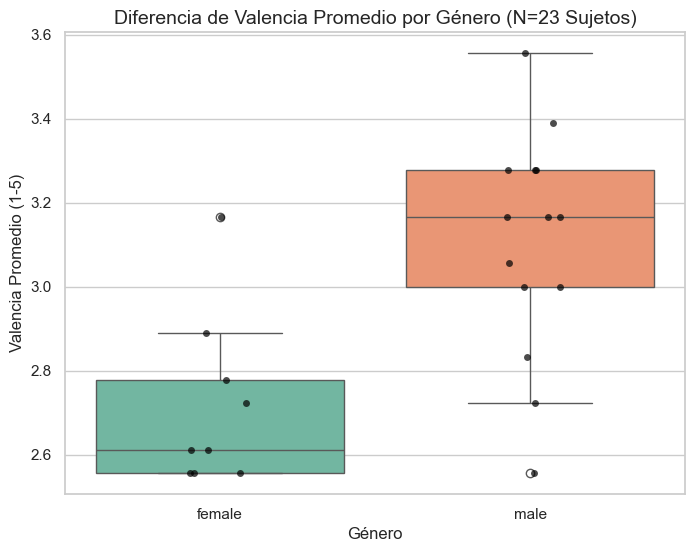

In [41]:
# Visualización del Hallazgo Significativo ---

print("--- Descriptivos: Valencia Promedio por Género (N=23) ---")
display(df_subjects_stats.groupby('gender',observed=False)['avg_valence'].describe())

plt.figure(figsize=(8, 6))

# Creamos un Boxplot para ver la mediana y los cuartiles
sns.boxplot(data=df_subjects_stats, 
            x='gender', 
            y='avg_valence', 
            palette='Set2',
            hue='gender',
            legend=False)

# Superponemos un Stripplot para ver los 23 puntos de datos individuales
sns.stripplot(data=df_subjects_stats, 
              x='gender', 
              y='avg_valence', 
              color='black', 
              alpha=0.7, 
              jitter=0.1)

plt.title('Diferencia de Valencia Promedio por Género (N=23 Sujetos)', fontsize=14)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Valencia Promedio (1-5)', fontsize=12)
plt.show()

---
## 6. Resumen de Hallazgos y Próximos Pasos (Dataset DREAMER)

Hemos completado el Análisis Exploratorio de Datos del dataset DREAMER.

### Hallazgos Clave
1.  **Estructura de Datos:** El dataset es anidado (`.mat`), pero pudo aplanarse en un dataframe de metadatos de 414 *trials* (23 sujetos x 18 videos). Se creó un segundo dataframe agregado ($N=23$) para un análisis estadístico robusto.
2.  **Calidad de Datos:** No hay valores nulos. Las duraciones de *baseline* son constantes (std=0), pero las de *estímulo* son variables y multimodales (indicando que los 18 videos tienen varias duraciones distintas).
3.  **Variables Objetivo (Emociones):**
    * Las puntuaciones (1-5) están razonablemente distribuidas, aunque `arousal` y `dominance` tienden a puntuaciones más altas (3-5).
    * `Arousal` y `Dominance` tienen una **correlación positiva fuerte y significativa** ($r=0.68$, $p < 0.001$). Los estados de calma se asocian con sumisión y los de excitación con dominancia.
    * `Valence` es estadísticamente independiente de `Arousal` y `Dominance`.
4.  **Análisis Bivariado (Significativo):**
    * Existe una **diferencia estadísticamente significativa** ($p=0.0043$) en la **valencia promedio** reportada entre **hombres y mujeres**. Los hombres (media=3.10) reportaron una valencia promedio significativamente más alta (más positiva) que las mujeres (media=2.72).
    * No hay diferencias significativas por género para `arousal` o `dominance`.
    * La `edad` no mostró una correlación significativa con ninguna emoción (aunque fue marginal para `arousal`, $p=0.0518$).

### Próximos Pasos (Pre-procesamiento y Modelado)
* **Feature Engineering:** El siguiente paso no es usar este `df_info`, sino volver a los datos crudos (`dreamer.Data`) e **iterar para extraer características** (features) de las señales de EEG (ej. potencia de bandas, asimetría) y ECG (ej. features de HRV).
* **Creación del Dataset de Modelado:** Se debe crear un nuevo DataFrame donde cada fila (414) contenga las *features* extraídas (ej. `eeg_alfa_ch1`, `ecg_rmssd`) y las etiquetas (`valence`, `arousal`).
* **Consideraciones del Modelo:**
    * Dado el hallazgo de `gender` vs `valence`, el `género` debería incluirse como una *feature* en el modelo final, ya que es un predictor significativo de la valencia.
    * Debido a la fuerte correlación entre `arousal` y `dominance`, un modelo podría tener dificultades para distinguirlos (multicolinealidad) o, alternativamente, se podría enfocar en predecir solo uno de ellos.

In [1]:
!jupyter nbconvert --to webpdf EDA_DREAMER.ipynb

[NbConvertApp] Converting notebook EDA_DREAMER.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 561766 bytes to EDA_DREAMER.pdf
